<a href="https://colab.research.google.com/github/s-choung/Research_utility/blob/main/stem_image_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torchvision
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())
import sys
!{sys.executable} -m pip install opencv-python matplotlib
!{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam2.git'

!mkdir -p images
!mkdir -p ../checkpoints/

!wget -P ../checkpoints/ https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt
!wget -P ../checkpoints/ https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt

PyTorch version: 2.5.1+cu121
Torchvision version: 0.20.1+cu121
CUDA is available: True
  Cloning https://github.com/facebookresearch/sam2.git to /tmp/pip-req-build-wt97wcn2
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/sam2.git /tmp/pip-req-build-wt97wcn2
  Resolved https://github.com/facebookresearch/sam2.git to commit 2b90b9f5ceec907a1c18123530e92e794ad901a4





  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 9.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.9 MB/s eta 0:00:00
  Created wheel for SAM-2: filename=SAM_2-1.0-cp3

In [ ]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image


if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )


np.random.seed(3)

def show_anns(anns, borders=True):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:, :, 3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.5]])
        img[m] = color_mask
        if borders:
            import cv2
            contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
            # Try to smooth contours
            contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
            cv2.drawContours(img, contours, -1, (0, 0, 1, 0.4), thickness=1)

    ax.imshow(img)

using device: cuda


## Example image

Mask generation completed in 41.73 seconds
Number of masks generated: 16


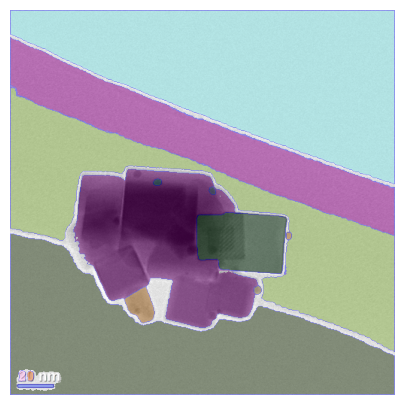

In [ ]:
import time
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt



#sam2_checkpoint = "../checkpoints/sam2.1_hiera_small.pt"
#model_cfg = "configs/sam2.1/sam2.1_hiera_s.yaml"

sam2_checkpoint = "../checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

sam2 = build_sam2(model_cfg, sam2_checkpoint, device=device, apply_postprocessing=False)

# Load and resize the image for faster processing
image_path = '1.jpg'  # Replace with your image path
image = Image.open(image_path).convert("RGB")
image = image.resize((image.width // 2, image.height // 2))  # Downscale image to half size
image_np = np.array(image)

# Faster mask generation
mask_generator = SAM2AutomaticMaskGenerator(
    model=sam2,
    points_per_side=64,  # Reduce point density for speed
    points_per_batch=2,  # Small batch size
    pred_iou_thresh=0.7,  # Standard IoU threshold
    stability_score_thresh=0.9,  # Higher stability score threshold
    crop_n_layers=0,  # Disable cropping for speed
    box_nms_thresh=0.9,  # Reduce overlap calculations
    min_mask_region_area=5.0,  # Filter out very small masks
    use_m2m=False  # Disable mask-to-mask refinement
)

# Measure wall time for mask generation
start_time = time.time()
masks = mask_generator.generate(image_np)
end_time = time.time()

# Print the elapsed time
print(f"Mask generation completed in {end_time - start_time:.2f} seconds")
print(f"Number of masks generated: {len(masks)}")
plt.figure(figsize=(5, 5))
plt.imshow(image)
show_anns(masks)
plt.axis('off')
plt.show()


Number of original masks generated: 12
Mask generation completed in 97.00 seconds
Number of filtered masks generated: 7


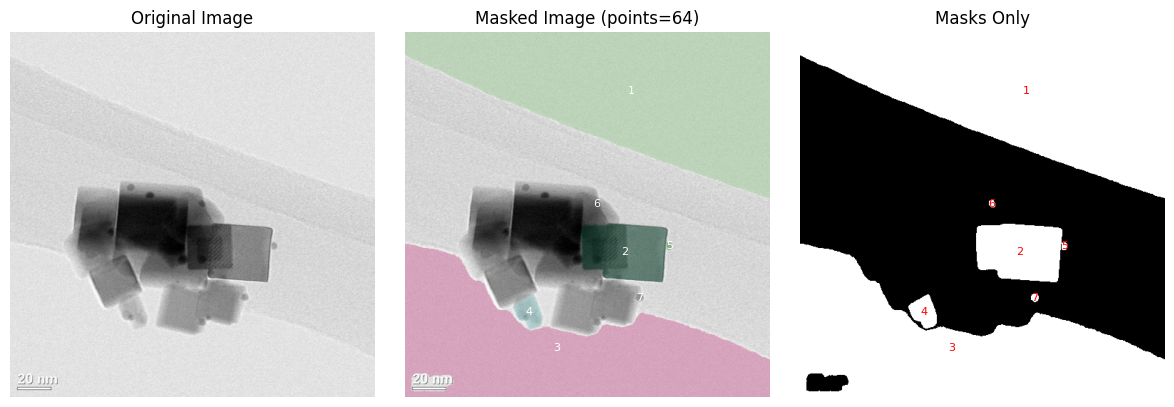

Mean Diameter: 35.24 nm
Mean Area: 2022.0 nm²


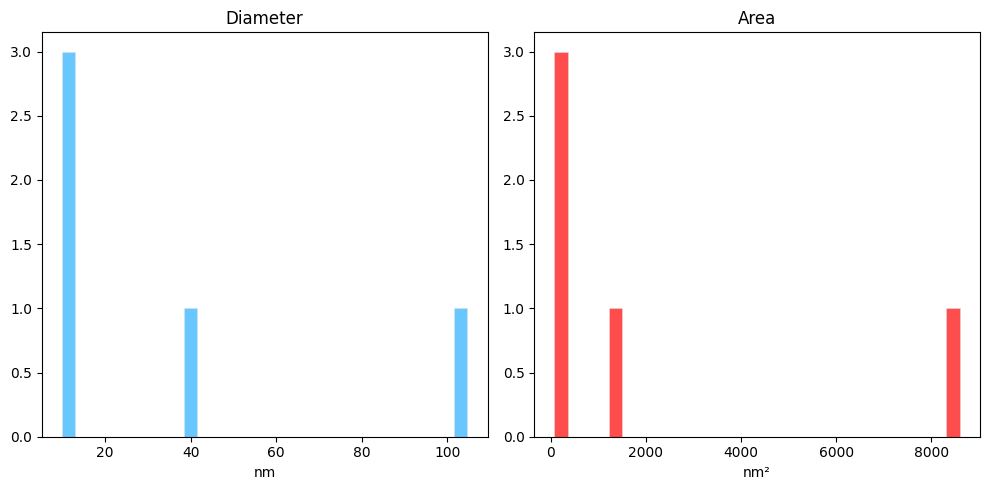

Number of original masks generated: 10
Mask generation completed in 86.68 seconds
Number of filtered masks generated: 5


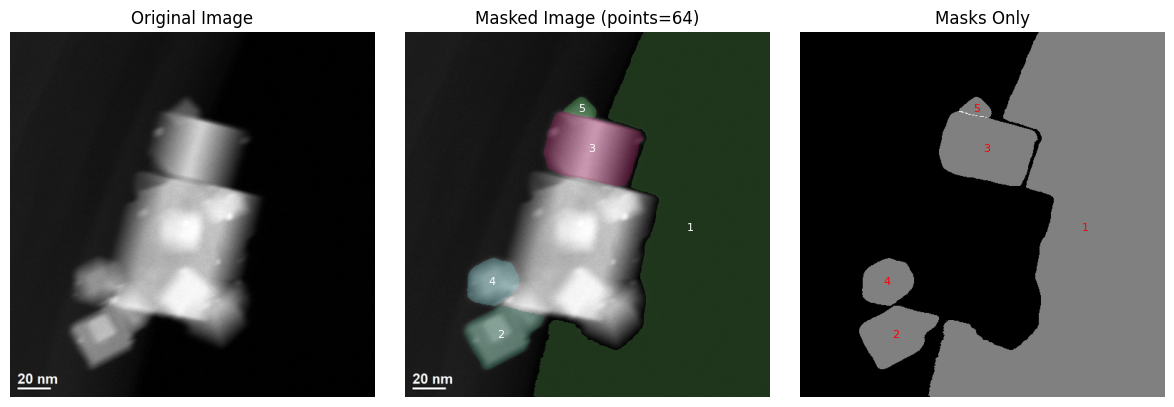

Mean Diameter: 76.5 nm
Mean Area: 5322.75 nm²


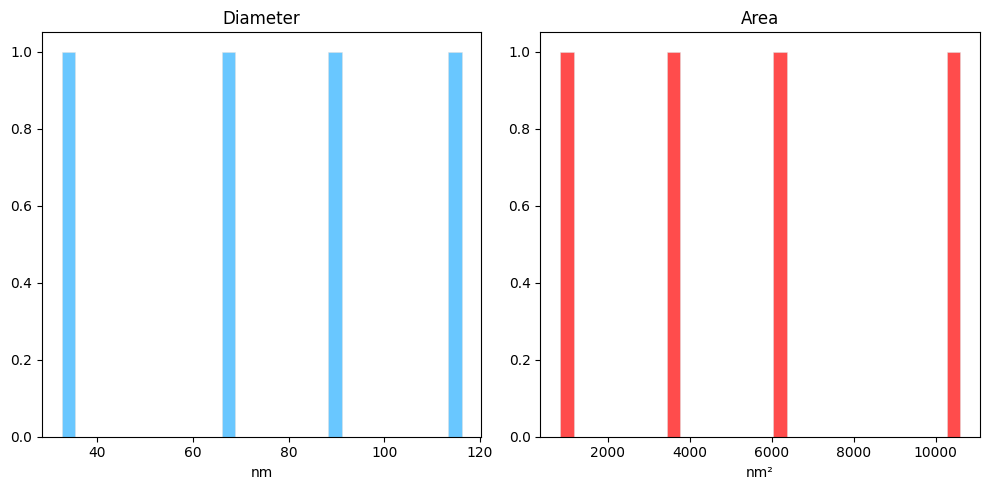

Number of original masks generated: 149
Mask generation completed in 105.92 seconds
Number of filtered masks generated: 97


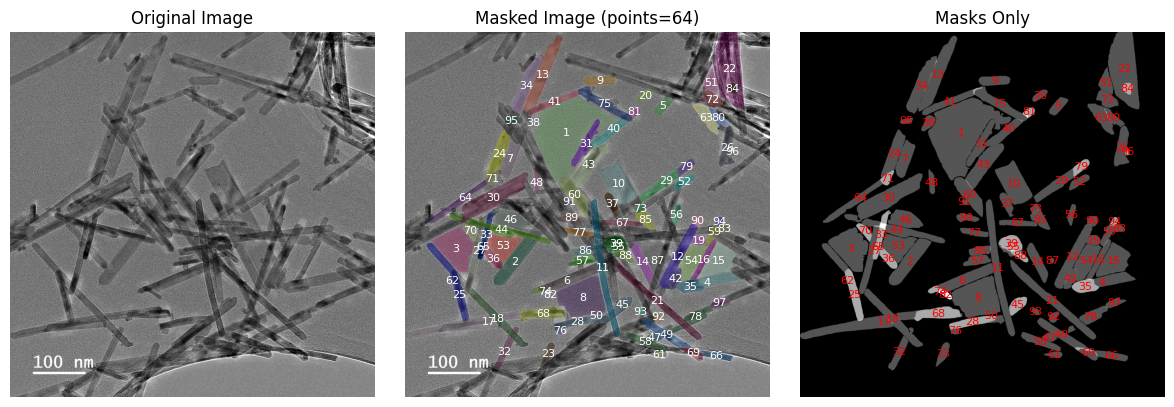

Mean Diameter: 110.98 nm
Mean Area: 11868.09 nm²


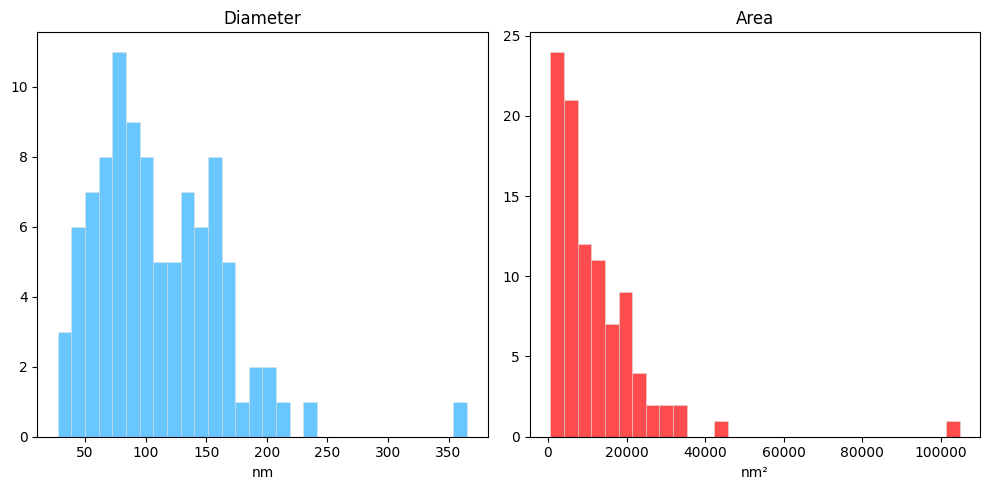

Number of original masks generated: 23
Mask generation completed in 156.25 seconds
Number of filtered masks generated: 13


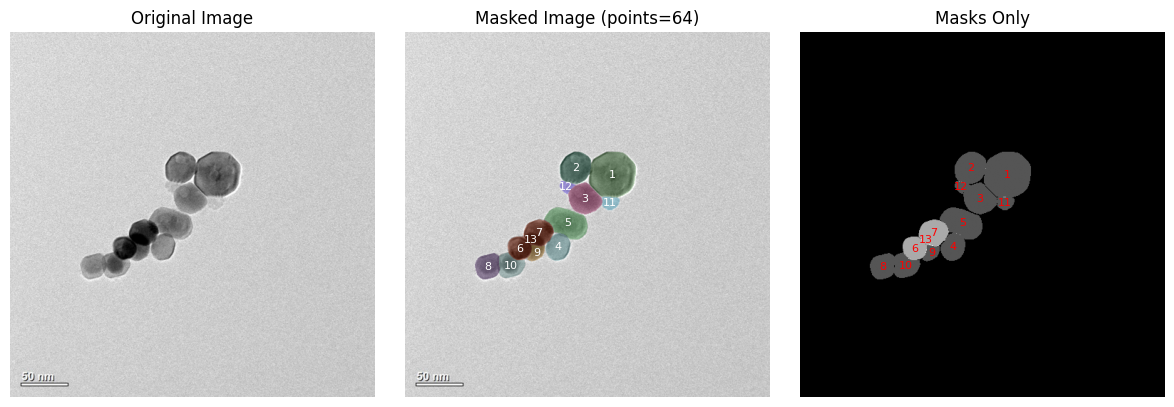

Mean Diameter: 38.17 nm
Mean Area: 1273.54 nm²


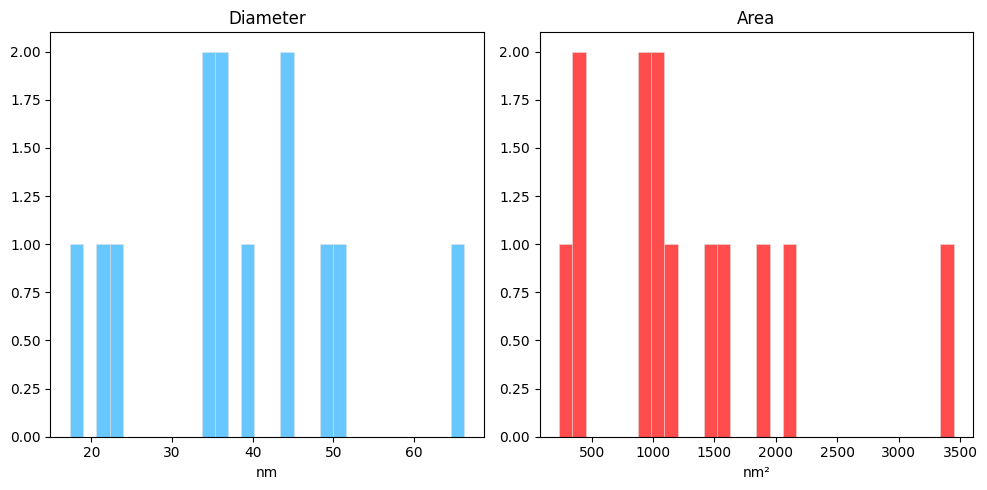

Number of original masks generated: 9
Mask generation completed in 96.29 seconds
Number of filtered masks generated: 4


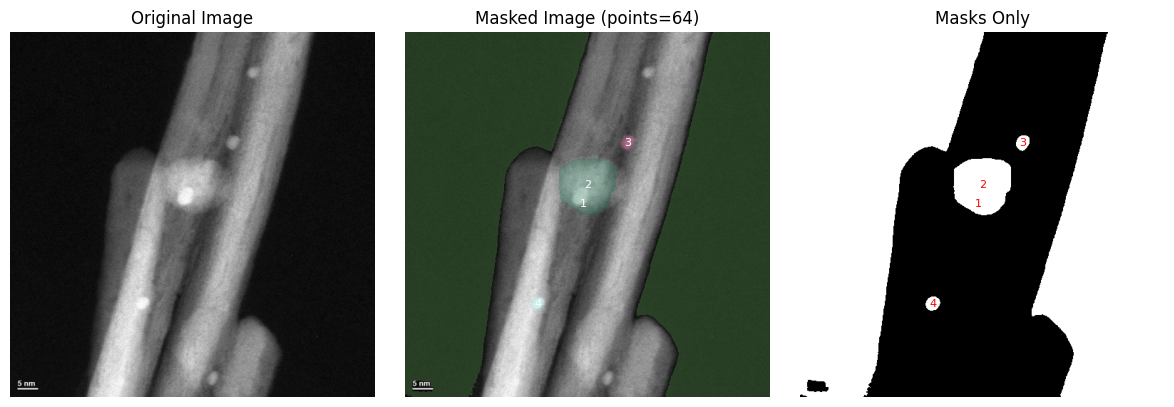

Mean Diameter: 40.77 nm
Mean Area: 1973.67 nm²


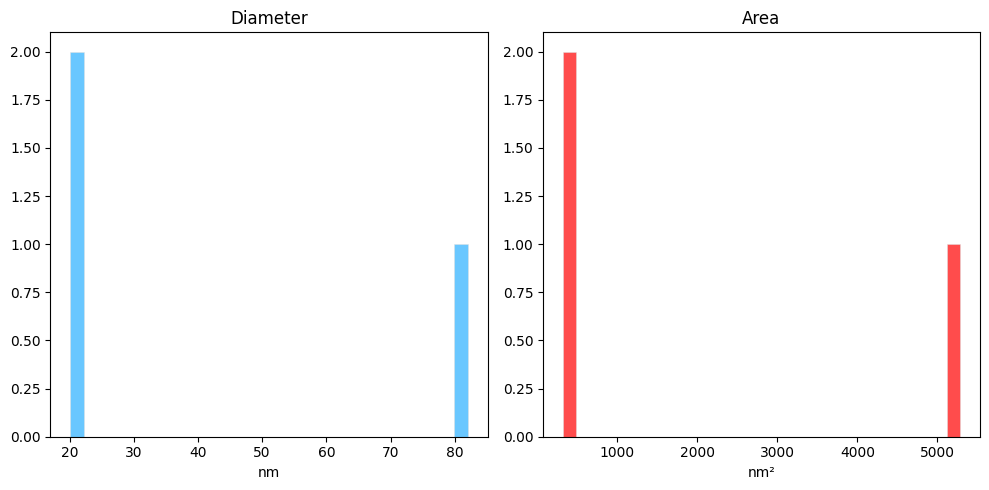

In [ ]:
import time
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def filter_masks(masks, image_shape, area_thresh=0.7, center_margin=0.1, intensity_thresh=5.0):  #### 배경 거르는 algorithm 수정 필요.
    height, width = image_shape[:2]
    total_pixels = height * width

    filtered_masks = []
    for mask in masks:
        segmentation = mask['segmentation']
        mask_area = np.sum(segmentation)

        # Area-based filtering (ignore very large masks)
        if mask_area / total_pixels > area_thresh:
            continue

        # Location-based filtering (ignore masks near the edges)
        y_coords, x_coords = np.where(segmentation)
        if len(y_coords) > 0 and len(x_coords) > 0:
            centroid_y = np.mean(y_coords)
            centroid_x = np.mean(x_coords)

            # Check if the centroid is within the central region
            if (
                centroid_x < width * center_margin
                or centroid_x > width * (1 - center_margin)
                or centroid_y < height * center_margin
                or centroid_y > height * (1 - center_margin)
            ):
                continue

        # If the mask passes all filters, keep it
        filtered_masks.append(mask)

    return filtered_masks

def generate_masks(image_path, sam2_checkpoint, model_cfg, points_per_side):

    # Build the SAM2 model
    sam2 = build_sam2(model_cfg, sam2_checkpoint, device="cuda", apply_postprocessing=False)

    # Load and resize the image
    image = Image.open(image_path).convert("RGB")
    image = image.resize((image.width // 2, image.height // 2))  # Downscale image to half size
    image_np = np.array(image)

    # Configure mask generator
    mask_generator = SAM2AutomaticMaskGenerator(  #### 여기 parameter들을 잘 수정하면 overlap되는것도 좀더 sensitive하게 가능
        model=sam2,
        points_per_side=points_per_side,
        points_per_batch=2,
        pred_iou_thresh=0.5,
        stability_score_thresh=0.9,
        crop_n_layers=0,
        box_nms_thresh=0.5,
        min_mask_region_area=5.0,
        use_m2m=True  # Enable mask refinement for better accuracy
    )

    # Measure wall time for mask generation
    start_time = time.time()
    masks = mask_generator.generate(image_np)
    end_time = time.time()
    print(f"Number of original masks generated: {len(masks)}")

    # Filter background masks
    masks = filter_masks(masks, image_np.shape)

    elapsed_time = end_time - start_time
    print(f"Mask generation completed in {elapsed_time:.2f} seconds")
    print(f"Number of filtered masks generated: {len(masks)}")

    return image_np, masks, elapsed_time


def plot_masks(image_np, masks, points_per_side):

    masked_image = create_masked_image_with_alpha(image_np, masks)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

    ax1.imshow(image_np)
    ax1.set_title("Original Image")
    ax1.axis("off")

    ax2.imshow(masked_image)
    ax2.set_title(f"Masked Image (points={points_per_side})")

    for i, mask in enumerate(masks, start=1):
        segmentation = mask['segmentation']
        # Compute the centroid of the mask
        y_coords, x_coords = np.where(segmentation)
        if len(y_coords) > 0 and len(x_coords) > 0:
            centroid_y = np.mean(y_coords)
            centroid_x = np.mean(x_coords)
            # Add label text to the centroid
            ax2.text(
                centroid_x, centroid_y, str(i),
                color="white", fontsize=8, ha="center", va="center")
    ax2.axis("off")
    ax3.imshow(np.sum([mask['segmentation'] for mask in masks], axis=0), cmap="gray")
    ax3.set_title("Masks Only")
    # Add labels to each mask
    for i, mask in enumerate(masks, start=1):
        segmentation = mask['segmentation']
        # Compute the centroid of the mask
        y_coords, x_coords = np.where(segmentation)
        if len(y_coords) > 0 and len(x_coords) > 0:
            centroid_y = np.mean(y_coords)
            centroid_x = np.mean(x_coords)
            # Add label text to the centroid
            ax3.text(
                centroid_x, centroid_y, str(i),
                color="red", fontsize=8, ha="center", va="center")
    ax3.axis("off")
    plt.tight_layout()
    plt.show()

def create_masked_image_with_alpha(image, masks, alpha=0.3):
    masked_image = image.copy()
    overlay = image.copy()
    num_masks = len(masks)
    np.random.seed(42)  # For reproducibility
    colors = np.random.randint(0, 255, size=(num_masks, 3))  # Random RGB colors
    for i, mask in enumerate(masks):
        segmentation = mask['segmentation']
        overlay[segmentation] = colors[i]  # Assign a unique color to each mask
    return np.uint8(image * (1 - alpha) + overlay * alpha)

from skimage.measure import regionprops_table, label
from skimage.segmentation import clear_border
import matplotlib.pyplot as plt
import numpy as np

def visualize_clear_border(segmentation, mask_index):

    cleared_segmentation = clear_border(segmentation)

    fig, axs = plt.subplots(1, 2, figsize=(4, 2))
    axs[0].imshow(segmentation, cmap='gray')
    axs[0].set_title(f"Original Mask {mask_index}")
    axs[0].axis('off')

    axs[1].imshow(cleared_segmentation, cmap='gray')
    axs[1].set_title(f"Cleared Mask {mask_index}")
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()


def calculate_segmented_areas_with_visualization(masks, pixel_size, visualize=False):

    Diameter = []
    Area = []

    for i, mask in enumerate(masks):
        segmentation = mask['segmentation']

        if visualize:
            visualize_clear_border(segmentation, i + 1)

        cleared_segmentation = clear_border(segmentation)

        props = regionprops_table(cleared_segmentation.astype(int), properties=['area'])
        areas = np.array(props['area'])

        areas_real = areas * pixel_size**2
        diameters = (np.sqrt(areas_real / np.pi)) * 2

        Area.extend(areas_real)
        Diameter.extend(diameters)

    print(f'Mean Diameter: {np.round(np.mean(Diameter), 2)} nm')
    print(f'Mean Area: {np.round(np.mean(Area), 2)} nm²')
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].hist(Diameter, bins=30, facecolor='#2ab0ff', edgecolor='#e0e0e0', linewidth=0.5, alpha=0.7)
    axs[0].set_title("Diameter")
    axs[0].set_xlabel("nm")
    axs[1].hist(Area, bins=30, facecolor='red', edgecolor='#e0e0e0', linewidth=0.5, alpha=0.7)
    axs[1].set_title("Area")
    axs[1].set_xlabel("nm²")
    plt.tight_layout()
    plt.show()

    return Diameter, Area



sam2_checkpoint = "../checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"


image_paths = ['1.jpg','2.jpg','3.jpg','4.jpg','5.jpg']
points_per_side_value = 64
for image_path in image_paths:
  image_np, masks, elapsed_time = generate_masks(
      image_path, sam2_checkpoint, model_cfg, points_per_side_value
  )
  plot_masks(image_np, masks, points_per_side_value)
  pixel_size = 1.0  # Replace with the actual pixel size in nm
  save_path = "segmented_areas.csv"
  diameters, areas = calculate_segmented_areas_with_visualization(masks, pixel_size)


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

# Clear GPU memory
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

# SAM model load
sam2_checkpoint = "../checkpoints/sam2.1_hiera_small.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_s.yaml"
sam2 = build_sam2(model_cfg, sam2_checkpoint, device='cpu', apply_postprocessing=False)

# Load and process the image
image_path = '1.jpg'  # Replace with your image path
image = Image.open(image_path).convert("RGB")
image_np = np.array(image)

# Generate masks using SAM2 with increased sensitivity
mask_generator_2 = SAM2AutomaticMaskGenerator(
    model=sam2,
    points_per_side=64,  # Higher point density for more masks
    points_per_batch=4,
    pred_iou_thresh=0.3,  # Lower IoU threshold for more masks
    stability_score_thresh=0.8,  # Lower stability score threshold
    stability_score_offset=0.7,
    crop_n_layers=1,
    box_nms_thresh=0.7,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=5.0,  # Allow smaller masks
    use_m2m=True,
)
masks2 = mask_generator_2.generate(image_np)

# Create a masked image overlay with transparency (alpha)
def create_masked_image_with_alpha(image, masks, alpha=0.5):
    masked_image = image.copy()
    overlay = image.copy()
    for mask in masks:
        segmentation = mask['segmentation']
        overlay[segmentation] = [255, 0, 0]  # Red color for the mask
    # Blend the original image and overlay using alpha
    masked_image = np.uint8(image * (1 - alpha) + overlay * alpha)
    return masked_image

masked_image = create_masked_image_with_alpha(image_np, masks2, alpha=0.5)

# Plot the results side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Original Image
ax1.imshow(image_np)
ax1.set_title("Original Image")
ax1.axis("off")

# Masked Image
ax2.imshow(masked_image)
ax2.set_title("Masked Image (with Transparency)")
ax2.axis("off")

plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/sam2/sam2_image_predictor.py:431: UserWarning: inputs.is_cuda() INTERNAL ASSERT FAILED at "sam2/csrc/connected_components.cu":215, please report a bug to PyTorch. inputs must be a CUDA tensor

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  masks = self._transforms.postprocess_masks(


KeyboardInterrupt: 

# using YOLO detection model
ultralytics

In [ ]:
!pip install ultralytics


image 1/1 /content/test1.png: 1280x1280 26 Particles, 504.9ms
Speed: 9.8ms preprocess, 504.9ms inference, 2.2ms postprocess per image at shape (1, 3, 1280, 1280)
Detected 26 objects


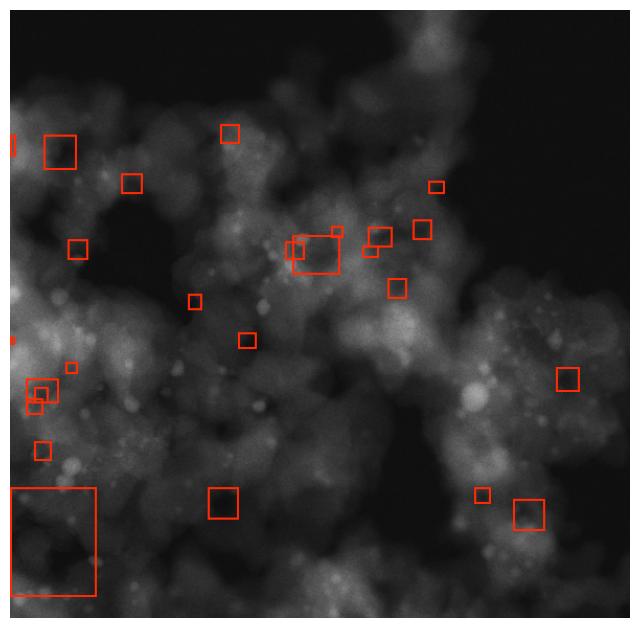

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image

def object_detection (img_x, img, path_to_image, img_size=1024, pred_score = 0.25, overlap_thr =0.5, save = False, s_txt = False):
    # Load the YOLO model
    path_to_weights_obj = "best12x.pt"  #"yolov8x.pt"  # Replace with your weights file
    model = YOLO(path_to_weights_obj)
    model.to('cuda')

    results = model.predict(source = img_x, imgsz = img_size, conf = pred_score, max_det= 4000, iou = overlap_thr, save_txt = s_txt)

    # Get bounding boxes
    for result in results:
        boxes = result.boxes

    bbox = boxes.xyxy.tolist()
    print(f"Detected {len(bbox)} objects")

    # Visualize bounding boxes
    res_plotted = results[0].plot(labels=False, line_width=2, img=img)
    plt.figure(figsize=(8, 8))
    plt.axis('off')
    plt.imshow(res_plotted)

    if save:
        plt.savefig(path_to_image, bbox_inches='tight', pad_inches=0)
    plt.show()

# Run detection
image_path = "test1.png"  # Replace with your image filename
image = Image.open(image_path).convert("RGB")
object_detection(image_path, image, "detected_image.png", img_size=1280, pred_score=0.1, overlap_thr=0.3, save=True)


In [ ]:
import shutil
import os

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define the folder path
folder_path = '/content/drive/My Drive/stem_detection'

# Create the folder if it doesn't exist
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder created at: {folder_path}")
else:
    print(f"Folder already exists at: {folder_path}")

# Copy SAM2 weights file to Google Drive
local_weights_path = "../checkpoints/sam2.1_hiera_large.pt"  # Full file path to weights
drive_weights_path = os.path.join(folder_path, 'sam2.1_hiera_large.pt')

try:
    shutil.copy(local_weights_path, drive_weights_path)
    print(f"Weights file saved to: {drive_weights_path}")
except FileNotFoundError:
    print(f"File not found: {local_weights_path}")

# Save test1.jpg, test2.jpg, and test3.jpg to Google Drive
local_image_paths = ["test1.jpg", "test2.jpg", "test3.jpg"]

for image_path in local_image_paths:
    drive_image_path = os.path.join(folder_path, os.path.basename(image_path))
    try:
        shutil.copy(image_path, drive_image_path)
        print(f"Image saved to: {drive_image_path}")
    except FileNotFoundError:
        print(f"File not found: {image_path}")
